# Fase 1 — EDA: Ames Housing

Objetivo: entender os dados **antes** de treinar qualquer modelo.

**Pré-requisito:** rodar o download dos dados:
```powershell
python scripts/download_data.py
```

In [4]:
import sys
from pathlib import Path

# Jupyter roda com cwd em notebooks/, então adicionamos a raiz do projeto ao path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data.load_data import load_data_description, load_test, load_train

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Carregar dados

In [5]:
train = load_train()
test = load_test()
description = load_data_description()

print(description[:500], "...\n")
train.head()

Ames Housing dataset description unavailable offline.
See Kaggle competition data_description.txt for full column docs.
 ...



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


## 2. Shape do dataset

In [6]:
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Target column present in train: {'SalePrice' in train.columns}")

Train shape: (1460, 81)
Test shape:  (292, 80)
Target column present in train: True


## 3. Tipos de colunas

In [7]:
numeric_cols = train.select_dtypes(include=["number"]).columns.tolist()
object_cols = train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numéricas: {len(numeric_cols)}")
print(f"Categóricas (object): {len(object_cols)}")

train.dtypes.value_counts()

Numéricas: 38
Categóricas (object): 43


object     43
int64      34
float64     4
Name: count, dtype: int64

## 4. Missing values

In [8]:
missing = (
    train.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing["missing_pct"] = (missing["missing_count"] / len(train) * 100).round(2)
missing = missing[missing["missing_count"] > 0]

print(f"Colunas com missing: {len(missing)}")
missing.head(20)

Colunas com missing: 19


,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


In [9]:
high_missing = missing[missing["missing_pct"] > 50]
print("Colunas com >50% missing (candidatas a remoção):")
high_missing

Colunas com >50% missing (candidatas a remoção):


,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73


## 5. Distribuição do target (`SalePrice`)

In [10]:
target = train["SalePrice"]

print(target.describe())
print(f"Skewness: {target.skew():.3f}")
print(f"Kurtosis: {target.kurtosis():.3f}")

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Skewness: 1.883
Kurtosis: 6.536


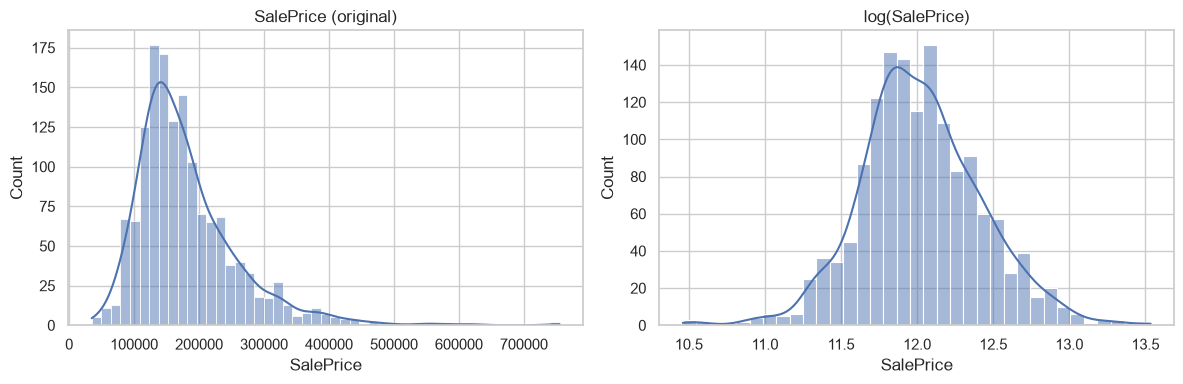

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(target, kde=True, ax=axes[0])
axes[0].set_title("SalePrice (original)")

sns.histplot(np.log1p(target), kde=True, ax=axes[1])
axes[1].set_title("log(SalePrice)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=120)
plt.show()

## 6. Correlação com `SalePrice`

In [12]:
corr_with_target = (
    train[numeric_cols].corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=abs, ascending=False)
)

corr_with_target.head(15)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

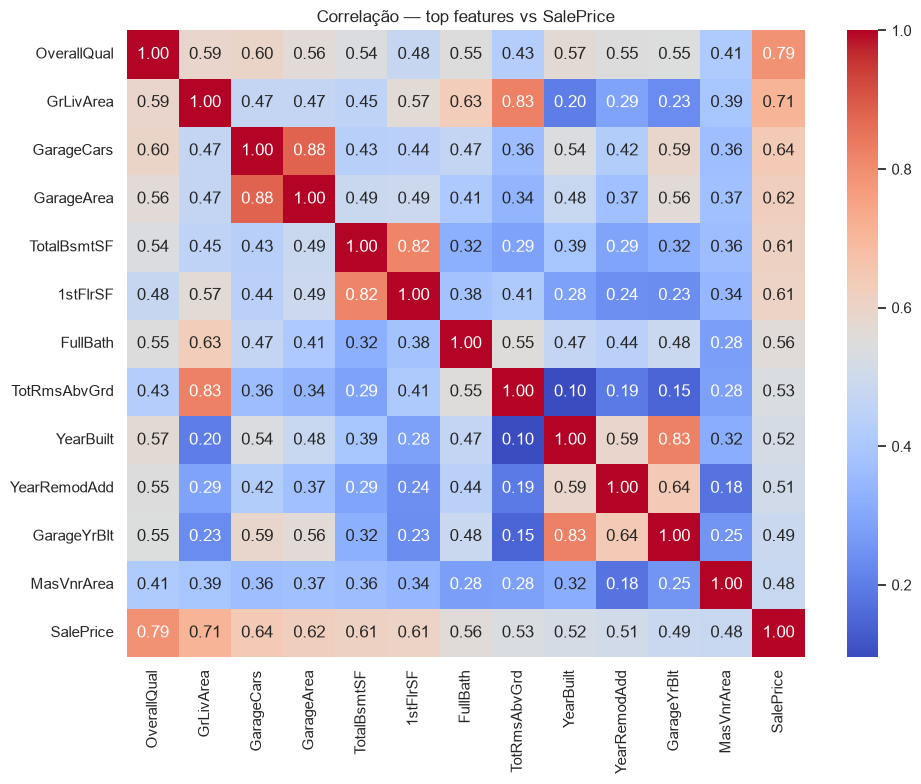

In [13]:
top_features = corr_with_target.abs().head(12).index.tolist()
heatmap_data = train[top_features + ["SalePrice"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlação — top features vs SalePrice")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=120)
plt.show()

## 7. Cardinalidade das categóricas

In [14]:
cardinality = (
    train[object_cols].nunique().sort_values(ascending=False).to_frame("unique_values")
)
cardinality.head(20)

,unique_values
Neighborhood,25
Exterior2nd,16
Exterior1st,15
Condition1,9
SaleType,9
HouseStyle,8
RoofMatl,8
Condition2,8
Functional,7
BsmtFinType2,6


## 8. Outliers visuais

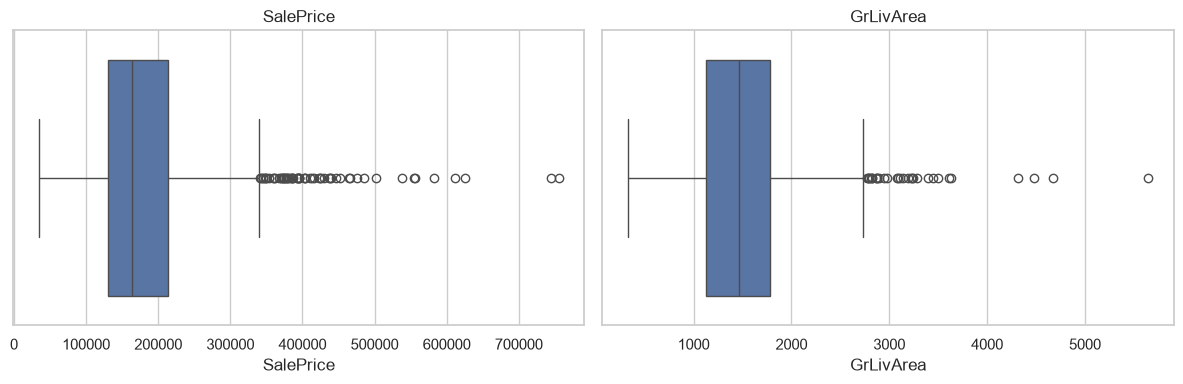

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=train["SalePrice"], ax=axes[0])
axes[0].set_title("SalePrice")

sns.boxplot(x=train["GrLivArea"], ax=axes[1])
axes[1].set_title("GrLivArea")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "outliers_boxplots.png", dpi=120)
plt.show()

## 9. Relações entre features importantes

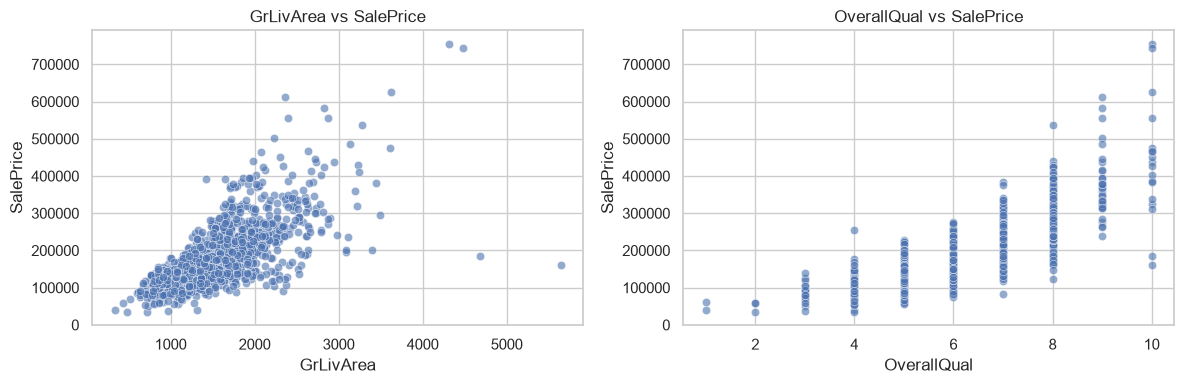

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", ax=axes[0], alpha=0.6)
axes[0].set_title("GrLivArea vs SalePrice")

sns.scatterplot(data=train, x="OverallQual", y="SalePrice", ax=axes[1], alpha=0.6)
axes[1].set_title("OverallQual vs SalePrice")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "scatter_key_features.png", dpi=120)
plt.show()

## 10. Features redundantes (correlação > 0.9)

In [17]:
corr_matrix = train[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "correlation"})
)
redundant_pairs = redundant_pairs[redundant_pairs["correlation"] > 0.9].sort_values(
    "correlation", ascending=False
)

print(f"Pares com correlação > 0.9: {len(redundant_pairs)}")
redundant_pairs.head(20)

Pares com correlação > 0.9: 0


,feature_a,feature_b,correlation


## 11. Respostas do EDA (preencha após analisar os outputs)

1. **O target precisa de transformação log?**  
   Resposta: _compare skewness e histogramas acima._

2. **Quais features têm >50% missing?**  
   Resposta: _veja tabela `high_missing`._

3. **Quais categóricas têm alta cardinalidade?**  
   Resposta: _veja tabela `cardinality`._

4. **Existem features redundantes?**  
   Resposta: _veja `redundant_pairs`._

